<a href="https://colab.research.google.com/github/vidaldominguez/uimp_deep_learning/blob/main/labs/DL_Regresi%C3%B3n_Keras_TF2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejemplo de regresión con Keras + TensorFlow

##NOTA IMPORTANTE
Estos notebook están compartidos únicamente con **permisos de lectura**, por tanto no podrás ni ejecutarlos ni modificarlos.

Para poder interactuar con el notebook **debes hacer una copia del mismo en tu Drive**. Esto puedes hacerlo desde el menú "Archivo" de Colaboratory.

Si durante la realización de la práctica tienes la sensación de que **el notebook no está funcionando bien**, puedes ir al menú "Entorno de ejecución" de Colaboratoty y "Reiniciar el entorno de ejecución".

Recuerda que para ejecutar un trozo de código debes situar el cursor en el mismo y presionar **MAYS+ENTER**.

## 1. Importar librerías necesarias
Lo primero que vamos a hacer es importar las librerías necesarias:



In [1]:
#Cargar librerias necesarias
import math
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

## 2. Generar los datos de entrenamiento

Ahora vamos a generar un conjunto de ejemplos para un problema de regresión. En concreto, nuestro problema tendrá ejemplos representados en $\mathbb{R}^2$. El valor real de estos ejemplos vendrá dado por la función $y=cos(x_0)+sin(x_1)$.

Esta función es claramente **no lineal**



In [2]:
seed = 2032  # semilla de números aleatorios
NE = 5000  # se van a generar NE ejemplos

np.random.seed(seed)  # se inicializalizan los números aleatorios

# Generar una matriz de NE filas y 2 columnas con datos uniformes entre -5 y 5
laX = np.random.uniform(-5, 5, size=[NE, 2])

laY = np.zeros((NE, 1)) # Reservar espacio para la Y

# Rellenar el vector de la Y
for i in range(NE):
    laY[i] = math.cos(laX[i, 0])+math.sin(laX[i, 1]) # ruido = np.random.normal(0,sigma)

print(laX)
print(laY)

[[ 4.5557887   3.84923263]
 [-2.22296771  2.30424712]
 [ 0.9677073  -2.77795226]
 ...
 [ 3.52344383 -2.2835793 ]
 [-2.81862311  4.66132362]
 [ 4.81409483  1.67149958]]
[[-0.8060032 ]
 [ 0.13595516]
 [ 0.21151034]
 ...
 [-1.68452131]
 [-1.94699356]
 [ 1.09646431]]


Podemos visulalizar los datos de entrenamiento ahora usando **matplotlib**.

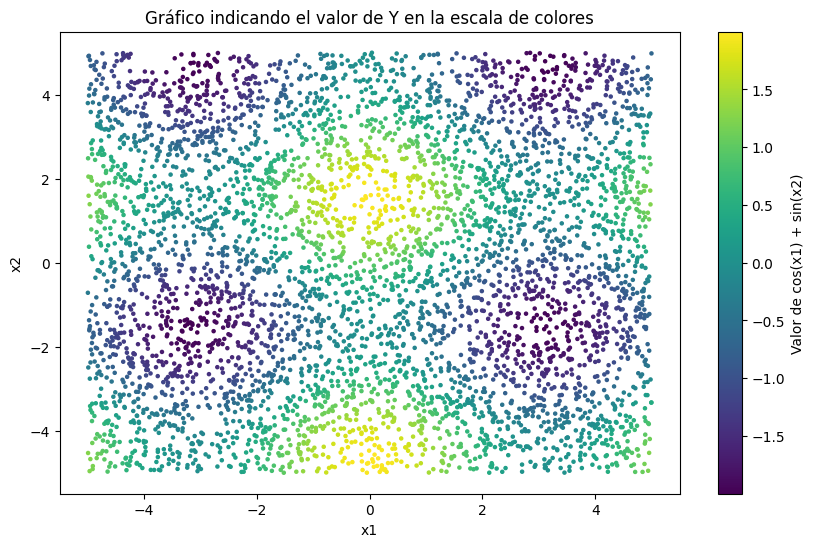

In [3]:
# Plotting
def plot_data(laX, laY):
  plt.figure(figsize=(10, 6))
  plt.scatter(laX[:, 0], laX[:, 1], c=laY,s=5)
  plt.colorbar(label='Valor de cos(x1) + sin(x2)')
  plt.title('Gráfico indicando el valor de Y en la escala de colores')
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.show()

plot_data(laX, laY)

## 3. Crear el modelo (modelo lineal)
Lo primero que vamos a hacer es crear una red sin capas ocultas. Esta red se conoce como perceptrón lineal y solo es capaz de resolver problemas lineales.

**Lee los comentarios del código detenidamente para entender lo que se está haciendo.**

*En la web de tensorflow puedes encontar tutoriales detallados*

Fíjate que la línea **print(model.summary())** imprime una representación en modo texto de la red y además indica el número de parámetros que se deben aprender en cada capa. En este caso hay una sola capa y los parámetros que hay que aprender son 3: los dos coeficientes que se multiplicarán por las entradas y el término independiente.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output_layer (Dense)            │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

None


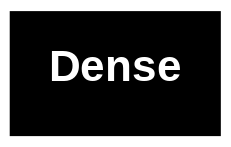

In [4]:
""" SE DEFINE LA RED """
keras.utils.set_random_seed(seed) # Fijar semilla del keras/tensorflow

n_input = 2      # Celdas en la capa de entrada (variables de entrada)
n_output = 1     # Celdas en la capa de salida (un valor numérico)

# Definir las capas del modelo
model = keras.Sequential()
model.add(keras.layers.Dense(n_output, input_dim=n_input, name="output_layer"))

# Como se puede ver, se crea un modelo secuencial donde cada capa añadida recibe
# como entrada la salida de la anterior.
# La dimensión de la entrada siempre se define en la primera capa del modelo
# (parámetro input_dim) => model.add(Dense(n_output, input_dim=n_input, name="output_layer"))

#Existe también una forma "funcional" de crear modelos. En este caso sería:
# in_layer = Input(shape =(n_input,))
# out_layer = Dense(n_output, name="out_layer")(in_layer)
#
# model = Model(inputs = [in_layer], outputs = [out_layer])

""" SELECCIONAR OPTIMIZADOR E INICIALIZAR PARÁMETROS """
# Learning rate del modelo. Es el alpha que multiplicará a la derivada cuando
# se va a hacer la modificación de los parámetros que se aprenden. En el vídeo
# del "Descenso del gradiente" se explica su función
learning_rate = 0.001

# Definir el optimizador a utilizar (SGD, descenso del gradiente estocástico)
# Consulta la ayuda para ver qué otros optimizadores hay
sgd = keras.optimizers.SGD(learning_rate=learning_rate)

# Compilar el modelo indicando la función de pérdida (loss) y el optimizador
model.compile(loss='mean_squared_error', optimizer=sgd)

""" SE VISUALIZA EL MODELO """
# Imprimir en modo texto finalmente el resumen/arquitectura de nuestro modelo
# Esta información permite conocer el número de parámetros que se han de aprender
print(model.summary())

# Obtener un fichero con la representación gráfica del modelo
keras.utils.plot_model(model, to_file='model.png')
# Después de ejecutar esta línea se genera el fichero 'model.png'. Para poder
# verlo, tienes que ir a la parte izquierda, acceder a la pestaña 'Archivos' y
# 'actualizar', aparecerá entonces el archivo y podrás verlo (doble click sobre
# el fichero 'model.png' o click con el botón derecho para descargarlo)


## 4. Entrenar el modelo
Una vez que ya hemos definido cómo va a ser nuestro modelo, vamos a entrenarlo para buscar los parámetros que hagan mínima la función de pérdida.

Para ello utilizaremos el método **fit**. Necesita que le suministremos los ejemplos (laX, laY), el tamaño del *batch* y el número de *epochs*.

El número de epochs es el número de veces que el algoritmo va a ver los ejemplos durante el entrenamiento.

El tamaño del batch es el número de ejemplos que se van a utilizar en cada actualización de los parámetros.

En el código vemos que elegimos como tamaño de batch 128. Como tenemos 5000 ejemplos y 5000/128=39 (la división no da exacta así que tendríamos un ultimo batch con los ejemplos restantes). Esto quiere decir que en 39 actualizaciones de los parámetros llegamos a los 5000 ejemplos, lo que completaría una epoch. Como le indicamos en el código que queremos 200 epochs, estaremos permitiendo que el algoritmo haga en total 39x200=7800 actualizaciones.

Con **verbose=2** le pedimos que nos muestre el error al finalizar cada epoch.

Fíjate que lo que retorna fit lo almacenamos en una variable que llamamos history. Más adelante la utilizaremos.

In [5]:
batch = 128    # Tamaño del batch
n_epochs = 200 # Número de epochs

#Entrenar el modelo a partir de los ejemplos de TRAIN creados en el punto 2
history = model.fit(laX, laY, batch_size=batch, epochs=n_epochs, verbose=2)

Epoch 1/200
40/40 - 0s - 8ms/step - loss: 6.0136
Epoch 2/200
40/40 - 0s - 3ms/step - loss: 2.2398
Epoch 3/200
40/40 - 0s - 2ms/step - loss: 1.2781
Epoch 4/200
40/40 - 0s - 2ms/step - loss: 1.0319
Epoch 5/200
40/40 - 0s - 2ms/step - loss: 0.9676
Epoch 6/200
40/40 - 0s - 2ms/step - loss: 0.9495
Epoch 7/200
40/40 - 0s - 2ms/step - loss: 0.9433
Epoch 8/200
40/40 - 0s - 2ms/step - loss: 0.9402
Epoch 9/200
40/40 - 0s - 2ms/step - loss: 0.9381
Epoch 10/200
40/40 - 0s - 2ms/step - loss: 0.9364
Epoch 11/200
40/40 - 0s - 3ms/step - loss: 0.9349
Epoch 12/200
40/40 - 0s - 2ms/step - loss: 0.9337
Epoch 13/200
40/40 - 0s - 2ms/step - loss: 0.9326
Epoch 14/200
40/40 - 0s - 2ms/step - loss: 0.9317
Epoch 15/200
40/40 - 0s - 2ms/step - loss: 0.9310
Epoch 16/200
40/40 - 0s - 2ms/step - loss: 0.9303
Epoch 17/200
40/40 - 0s - 2ms/step - loss: 0.9298
Epoch 18/200
40/40 - 0s - 3ms/step - loss: 0.9293
Epoch 19/200
40/40 - 0s - 2ms/step - loss: 0.9289
Epoch 20/200
40/40 - 0s - 4ms/step - loss: 0.9285
Epoch 21/

##5. Función para dibujar la gráfica del error
Tras realizar el entrenamiento con fit, almacenamos lo que retorna ese método en una variable que llamamos history.

Definimos ahora la función **plot_history** que recibiendo lo retornado por fit, crea un gráfico en el que se ve la evolución del error que se está minimizando en función de la epoch en la que se está.

Máximo error: 6.013580322265625
Mínimo error: 0.9265738129615784


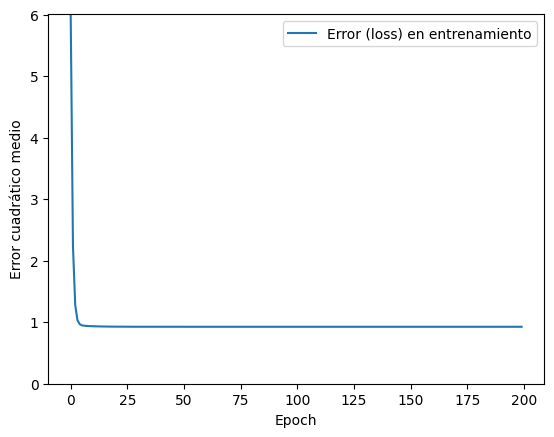

In [6]:
def plot_history(history):
  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Error cuadrático medio')
  plt.plot(history.epoch, np.array(history.history['loss']),
           label='Error (loss) en entrenamiento')
  plt.legend()
  plt.ylim([0, max(1,max(np.array(history.history['loss'])))])

plot_history(history)
print("Máximo error:",max(np.array(history.history['loss'])))
print("Mínimo error:",min(np.array(history.history['loss'])))


Otra manera de verificar que la solución es un modelo lineal podría ser pintando las predicciones hechas por el modelo sobre los datos de entrenamiento:

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


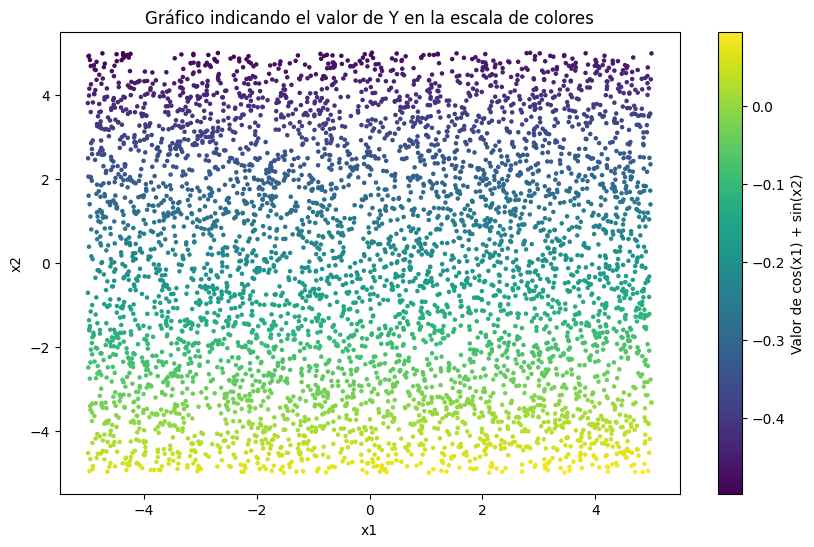

In [7]:
laY_pred = model.predict(laX)
plot_data(laX, laY_pred)


##6. Crear un modelo no lineal
El modelo anterior tiene una limitación muy grande: es un modelo lineal y eso le impide adaptarse de manera apropiada para resolver problemas no lineales.

Aun así, logra bajar el error hasta 0.926.

Vamos a ver ahora lo que sucede si creamos un modelo no lineal. Para ello vamos a incluir una capa oculta que tenga como función de activación la función **ReLU**.

Observa con detenimiento cómo se añade la capa, ya que tendrás posteriormente que añadir más capas.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1_layer (Dense)           │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

None


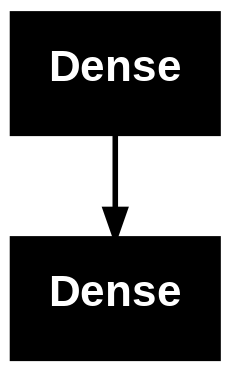

In [8]:
""" SE DEFINE LA RED """
keras.utils.set_random_seed(seed) # Fijar semilla del keras/tensorflow

n_input = 2      # Celdas en la capa de entrada (variables de entrada)
n_hidden1 = 10   # Celdas en la capa oculta
n_output = 1     # Celdas en la capa de salida (un valor numérico)

# Definir las capas del modelo
model = keras.Sequential()
model.add(keras.layers.Dense(n_hidden1, input_dim=n_input,activation='relu', name="hidden1_layer"))
model.add(keras.layers.Dense(n_output,name="output_layer"))

# Como se puede ver, se crea un modelo secuencial donde cada capa añadida recibe
# como entrada la salida de la anterior.
# La dimensión de la entrada siempre se define en la primera capa del modelo
# (parámetro input_dim) => model.add(Dense(n_hidden1, input_dim=n_input, name="hidden1_layer"))


#Existe también una forma "funcional" de crear modelos. En este caso sería:
# in_layer = Input(shape =(n_input,))
# hidden_layer = Dense(n_hidden1, name="hidden1_layer",activation='relu')(in_layer)
# out_layer = Dense(n_output, name="out_layer")(hidden_layer)
#
# model = Model(inputs = [in_layer], outputs = [out_layer])

""" SE DEFINE EL MODELO """

# Learning rate del modelo. Es el alpha que multiplicará a la derivada cuando
# se va a hacer la modificación de los parámetros que se aprenden. En el vídeo
# del "Descenso del gradiente" se explica su función
learning_rate = 0.001

# Definir el optimizador a utilizar (SGD, descenso del gradiente estocástico)
sgd = keras.optimizers.SGD(learning_rate=learning_rate)

# Compilar el modelo indicando la función de pérdida (loss) y el optimizador
model.compile(loss='mean_squared_error', optimizer=sgd)

""" SE VISUALIZA EL MODELO """

# Imprimir en modo texto finalmente el resumen/arquitectura de nuestro modelo
# Esta información permite conocer el número de parámetros que se han de aprender
print(model.summary())

# Obtener un fichero con la representación gráfica del modelo
keras.utils.plot_model(model, to_file='model.png')
# Después de ejecutar esta línea se genera el fichero 'model.png'. Para poder
# verlo, tienes que ir a la parte izquierda, acceder a la pestaña 'Archivos' y
# 'actualizar', aparecerá entonces el archivo y podrás verlo (doble click sobre
# el fichero 'model.png' o click con el botón derecho para descargarlo)

##7. Y lo ejecutamos
Ponemos **verbose=0** y así no tendremos que hacer tanto scroll. Eso sí, el resultado final tardará en aparecer unos segundos.

Máximo error: 1.2144862413406372
Máximo error: 0.37136971950531006


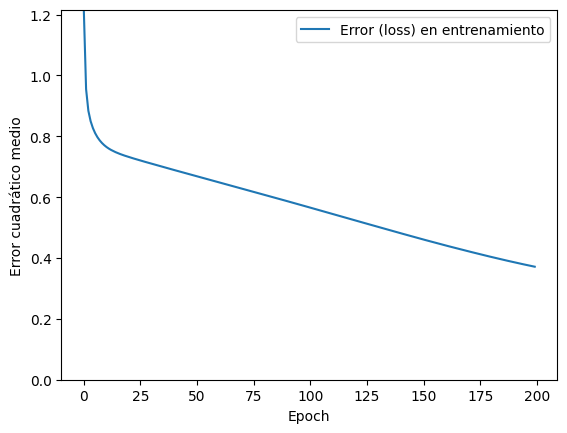

In [9]:
#Entrenar el modelo a partir de los ejemplos de TRAIN creados en el punto 2
history = model.fit(laX, laY, batch_size=batch, epochs=n_epochs, verbose=0 )

plot_history(history)
print("Máximo error:",max(np.array(history.history['loss'])))
print("Máximo error:",min(np.array(history.history['loss'])))

Como puedes ver, el error se ha hecho más pequeño. Esto es normal, ya que una red con una capa oculta ya es capaz de aprender funciones no lineales.

Si vuelves a realizar el entrenamiento con **learning_rate = 0.01** verás que es capaz de reducir el error mucho más.

En este caso, si pintamos las predicciones hechas por la red, veremos que está aprendiendo un modelo no lineal.

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


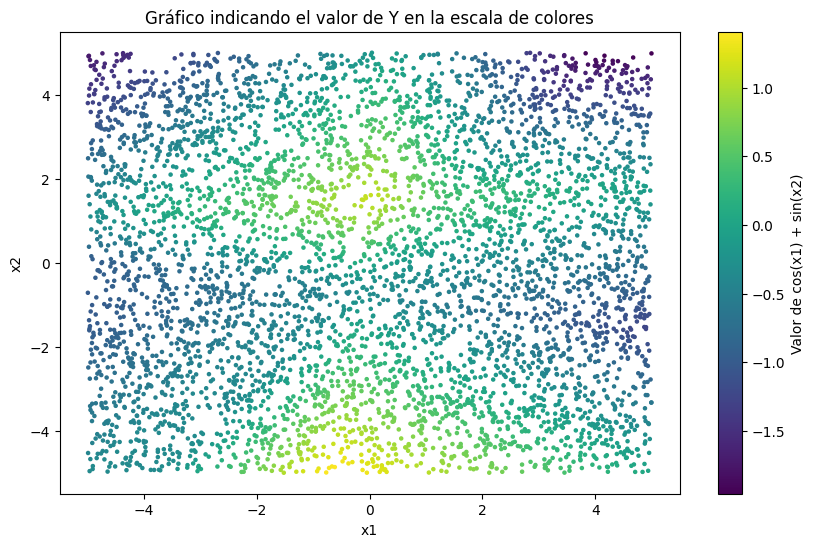

In [10]:
laY_pred = model.predict(laX)
plot_data(laX, laY_pred)

##8. Crea tú ahora una red con 2 capas ocultas
Debes crear una red con 2 capas ocultas. La primera con 6 celdas y la segunda con 4 celdas.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1_layer (Dense)           │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

None


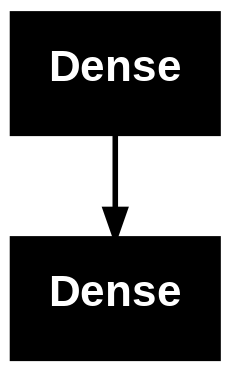

In [11]:
""" SE DEFINE LA RED """
keras.utils.set_random_seed(seed) # Fijar semilla del keras/tensorflow

###
### AQUÍ DEBES ESCRIBIR EL CÓDIGO NECESARIO PARA CREAR LA RED SOLICITADA
###

""" SE DEFINE EL MODELO """

# Learning rate del modelo. Es el alpha que multiplicará a la derivada cuando
# se va a hacer la modificación de los parámetros que se aprenden. En el vídeo
# del "Descenso del gradiente" se explica su función
learning_rate = 0.001

# Definir el optimizador a utilizar (SGD, descenso del gradiente estocástico)
sgd = keras.optimizers.SGD(learning_rate=learning_rate)

# Compilar el modelo indicando la función de pérdida (loss) y el optimizador
model.compile(loss='mean_squared_error', optimizer=sgd)

""" SE VISUALIZA EL MODELO """

# Imprimir en modo texto finalmente el resumen/arquitectura de nuestro modelo
# Esta información permite conocer el número de parámetros que se han de aprender
print(model.summary())

# Obtener un fichero con la representación gráfica del modelo
keras.utils.plot_model(model, to_file='model.png')
# Después de ejecutar esta línea se genera el fichero 'model.png'. Para poder
# verlo, tienes que ir a la parte izquierda, acceder a la pestaña 'Archivos' y
# 'actualizar', aparecerá entonces el archivo y podrás verlo (doble click sobre
# el fichero 'model.png' o click con el botón derecho para descargarlo)

Ejecuta el siguiente código para ver el rendimiento de la red que acabas de crear.

Máximo error: 0.36982354521751404
Mínimo error: 0.24014826118946075


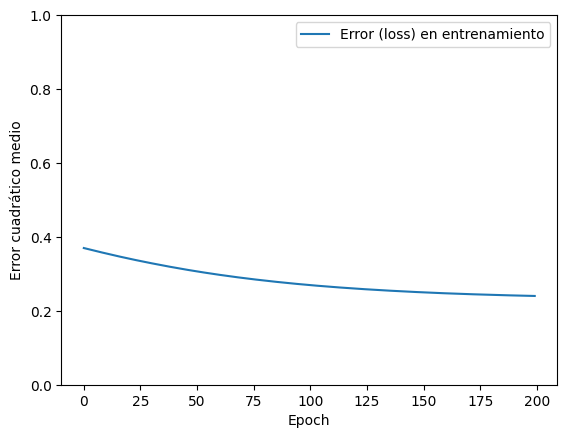

In [12]:
#Entrenar el modelo a partir de los ejemplos de TRAIN creados en el punto 2
history = model.fit(laX, laY, batch_size=batch, epochs=n_epochs, verbose=0 )

plot_history(history)
print("Máximo error:",max(np.array(history.history['loss'])))
print("Mínimo error:",min(np.array(history.history['loss'])))

Puedes probar otras configuraciones de red para intentar obtener mejores resultados.